In [10]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
cancer = load_breast_cancer()

In [6]:
x = cancer.data
y = cancer.target

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

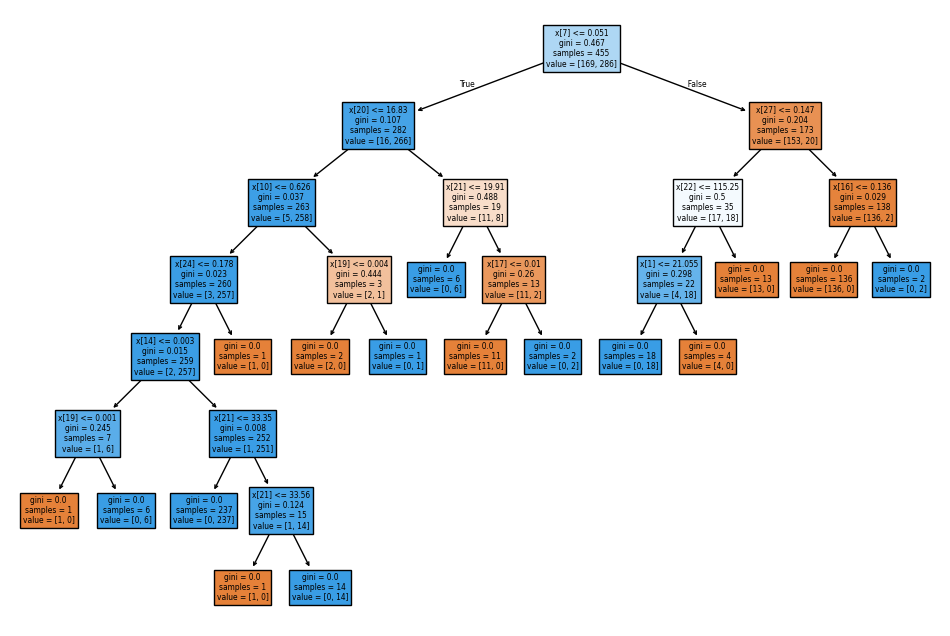

In [11]:
plt.figure(figsize=(12,8))
plot_tree(model,filled=True)
plt.show()

In [12]:
accuracy_score(y_train,model.predict(x_train))

1.0

In [13]:
accuracy_score(y_test,model.predict(x_test))

0.9385964912280702

#this shows overfitting as training data shows 100%

# so we use hyperparameters

In [15]:
model = DecisionTreeClassifier(max_depth=2)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2)

In [17]:
accuracy_score(y_train,model.predict(x_train))


0.9296703296703297

In [18]:
accuracy_score(y_test,model.predict(x_test))

0.9298245614035088

In [19]:
model = DecisionTreeClassifier(max_depth=2,min_samples_split=10,min_samples_leaf=5)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=5, min_samples_split=10)

In [20]:
accuracy_score(y_train,model.predict(x_train))

0.9296703296703297

In [21]:
accuracy_score(y_test,model.predict(x_test))

0.9298245614035088

In [22]:
param_grid = {
    'max_depth' : [2,3,4,5],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,5]
}

grid = GridSearchCV(DecisionTreeClassifier(),param_grid,cv=5)
grid.fit(x_train,y_train)
print(grid.best_params_)

best_model = grid.best_estimator_
accuracy_score(y_test,best_model.predict(x_test))

{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}


0.9385964912280702